# Model Predictions (coupler_NCap_cap_matrix)
## Capacitance --> Qiskit Metal

Inverse model with surrogate-defined loss

## Configuration

In [1]:
# The parameter file is where the hyperparameters are set. 
# It's reccomended to look at that file first, its interesting and you can set stuff there

from parameters import *

## Library

In [2]:
import os, gc, math
from pathlib import Path
import numpy as np
import pandas as pd
from pandas import json_normalize
import joblib
import matplotlib.pyplot as plt

os.environ['TF_XLA_FLAGS'] = '--tf_xla_enable_xla_devices'
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import tensorflow as tf
from tensorflow.keras.models import load_model, Model
from tensorflow.keras.layers import Dense

## Dataset

### Load

In [3]:
# Load the one-hot encoded data (from ml_00 preprocessing)

# inputs are the capacitance values (what we want to invert)
X_train = np.load(f'{DATA_DIR}/npy/x_train_one_hot_encoding_scaled.npy', allow_pickle=True)
X_val   = np.load(f'{DATA_DIR}/npy/x_val_one_hot_encoding_scaled.npy', allow_pickle=True)
X_test  = np.load(f'{DATA_DIR}/npy/x_test_one_hot_encoding_scaled.npy', allow_pickle=True)

# Qiskit Metal params in one-hot encoding (ground truth for reference)
y_train = np.load(f'{DATA_DIR}/npy/y_train_one_hot_encoding_scaled.npy', allow_pickle=True)
y_val   = np.load(f'{DATA_DIR}/npy/y_val_one_hot_encoding_scaled.npy', allow_pickle=True)
y_test  = np.load(f'{DATA_DIR}/npy/y_test_one_hot_encoding_scaled.npy', allow_pickle=True)

# column names
with open('X_names', 'r') as f:
    cap_column_names = f.read().splitlines()

oh_col_names   = np.load('y_columns.npy', allow_pickle=True).astype(str).tolist()
cont_col_names = np.load('y_columns_continuous.npy', allow_pickle=True).astype(str).tolist()
fc_oh_col_names = np.load('y_columns_fingers.npy', allow_pickle=True).astype(str).tolist()

# Extract finger count integer values from column names
fc_values = sorted([int(c.split('_')[-1]) for c in fc_oh_col_names])

n_continuous = len(cont_col_names)
n_fc_onehot  = len(fc_oh_col_names)

print(f'Inputs (Capacitance):     {X_train.shape[1]} columns')
print(f'Outputs (one-hot Qiskit): {y_train.shape[1]} columns ({n_continuous} continuous + {n_fc_onehot} finger_count one-hot)')
print(f'Finger count values: {fc_values}')
print(f'\nCapacitance columns:  {cap_column_names}')
print(f'Continuous Qiskit columns: {cont_col_names}')
print(f'Finger count one-hot columns: {fc_oh_col_names}')

Inputs (Capacitance):     6 columns
Outputs (one-hot Qiskit): 13 columns (3 continuous + 10 finger_count one-hot)
Finger count values: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

Capacitance columns:  ['top_to_top', 'top_to_bottom', 'top_to_ground', 'bottom_to_bottom', 'bottom_to_ground', 'ground_to_ground']
Continuous Qiskit columns: ['design_options.cap_gap', 'design_options.cap_width', 'design_options.finger_length']
Finger count one-hot columns: ['design_options.finger_count_1', 'design_options.finger_count_2', 'design_options.finger_count_3', 'design_options.finger_count_4', 'design_options.finger_count_5', 'design_options.finger_count_6', 'design_options.finger_count_7', 'design_options.finger_count_8', 'design_options.finger_count_9', 'design_options.finger_count_10']


### Define conversion layer

In [4]:
class OneHotToLinearLayer(tf.keras.layers.Layer):
    def __init__(self, n_continuous, fc_values, fc_data_min, fc_data_range,
                 fc_linear_idx, cont_scale_a, cont_scale_b, **kwargs):
        kwargs.setdefault('trainable', False)
        super().__init__(**kwargs)
        self._n_cont    = n_continuous
        self._fc_vals   = tf.constant([fc_values], dtype=tf.float32)
        self._fc_min    = tf.constant(fc_data_min, dtype=tf.float32)
        self._fc_range  = tf.constant(fc_data_range, dtype=tf.float32)
        self._fc_idx    = fc_linear_idx
        self._scale_a   = tf.constant(cont_scale_a, dtype=tf.float32)
        self._scale_b   = tf.constant(cont_scale_b, dtype=tf.float32)
        self._cfg = dict(n_continuous=n_continuous, fc_values=fc_values,
                         fc_data_min=fc_data_min, fc_data_range=fc_data_range,
                         fc_linear_idx=fc_linear_idx,
                         cont_scale_a=list(cont_scale_a) if hasattr(cont_scale_a, '__iter__') else cont_scale_a,
                         cont_scale_b=list(cont_scale_b) if hasattr(cont_scale_b, '__iter__') else cont_scale_b)

    def call(self, inputs):
        continuous = inputs[:, :self._n_cont]
        fc_onehot  = inputs[:, self._n_cont:]
        fc_vals  = tf.cast(self._fc_vals, inputs.dtype)
        fc_min   = tf.cast(self._fc_min, inputs.dtype)
        fc_range = tf.cast(self._fc_range, inputs.dtype)
        scale_a  = tf.cast(self._scale_a, inputs.dtype)
        scale_b  = tf.cast(self._scale_b, inputs.dtype)
        fc_raw = tf.reduce_sum(fc_onehot * fc_vals, axis=1, keepdims=True)
        fc_scaled = (fc_raw - fc_min) / fc_range
        cont_rescaled = continuous * scale_a + scale_b
        return tf.concat([
            cont_rescaled[:, :self._fc_idx],
            fc_scaled,
            cont_rescaled[:, self._fc_idx:]
        ], axis=1)

    def get_config(self):
        config = super().get_config()
        config.update(self._cfg)
        return config

### Visualize model

In [5]:
# Decide which model file to use
encoding = 'surrogate_defined_loss'
chosen_path = f'model/best_keras_model_{encoding}.keras'
X_test_cur = np.asarray(X_test)
y_test_cur = np.asarray(y_test)

# Load output headers (capacitance column names — the reconstruction target)
headers = cap_column_names
print(f'Model path: {chosen_path}')
print(f'Capacitance output headers: {headers}')

Model path: model/best_keras_model_surrogate_defined_loss.keras
Capacitance output headers: ['top_to_top', 'top_to_bottom', 'top_to_ground', 'bottom_to_bottom', 'bottom_to_ground', 'ground_to_ground']


In [6]:
#look at the best model, ooh so pretty
tf.keras.backend.clear_session()
gc.collect()
try:
    tf.config.experimental.reset_memory_stats('GPU:0')
except Exception:
    pass

with tf.device('/CPU:0'):
    combined_model = load_model(chosen_path, compile=False,
        custom_objects={'OneHotToLinearLayer': OneHotToLinearLayer})
    inverse_model = combined_model.get_layer('inverse_model')
    
    # get both the reconstructed capacitance and the predicted Qiskit params
    cap_pred = combined_model.predict(X_test_cur, verbose=0)
    qiskit_pred = inverse_model.predict(X_test_cur, verbose=0)

print(f'\n—— {os.path.basename(chosen_path)} ——')
print('\nCombined model (inverse + conversion + frozen surrogate):')
combined_model.summary()
print('\nInverse model only:')
inverse_model.summary()
print(f'\nSamples: {len(X_test_cur)} | Cap targets dim: {X_test_cur.shape[1]} | Qiskit OH dim: {y_test_cur.shape[1]}')

I0000 00:00:1772118616.332997 1570860 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1063 MB memory:  -> device: 0, name: NVIDIA A100 80GB PCIe MIG 4g.40gb, pci bus id: 0000:00:10.0, compute capability: 8.0
I0000 00:00:1772118616.695290 1571524 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.



—— best_keras_model_surrogate_defined_loss.keras ——

Combined model (inverse + conversion + frozen surrogate):


Model: "combined_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ combined_input (InputLayer)     │ (None, 6)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inverse_model (Sequential)      │ (None, 13)             │        71,565 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ oh_to_linear                    │ (None, 4)              │             0 │
│ (OneHotToLinearLayer)           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 6)              │         8,806 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 80,371 (313.95 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ fc0 (Dense)                     │ (None, 64)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_relu0 (LeakyReLU)         │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout0 (Dropout)              │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_relu1 (LeakyReLU)         │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 512)            │        33,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_relu2 (LeakyReLU)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc3 (Dense)                     │ (None, 64)             │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_relu3 (LeakyReLU)         │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout3 (Dropout)              │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qiskit_output_oh (Dense)        │ (None, 13)             │           845 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 71,565 (279.55 KB)

 Trainable params: 71,565 (279.55 KB)

 Non-trainable params: 0 (0.00 B)


Samples: 65 | Cap targets dim: 6 | Qiskit OH dim: 13


In [7]:
# look at some more specific model params
inv = combined_model.get_layer('inverse_model')

neurons_per_layer = [
    l.units for l in inv.layers
    if isinstance(l, Dense) and l.name.startswith('fc')
]
print('Best NEURONS_PER_LAYER:', neurons_per_layer)

dropouts = [
    (l.name, float(l.rate)) for l in inv.layers
    if isinstance(l, tf.keras.layers.Dropout)
]
if dropouts:
    print('Best DROPOUT rate(s):', dropouts)
else:
    print('Best DROPOUT rate(s): none found')

Best NEURONS_PER_LAYER: [64, 64, 512, 64]
Best DROPOUT rate(s): [('dropout0', 0.0), ('dropout1', 0.0), ('dropout2', 0.0), ('dropout3', 0.0)]


# Scaled

In [8]:
N_SAMPLES_TO_SHOW = 50 # change this to print more stuff

X_test_cur = np.asarray(X_test_cur)
y_test_cur = np.asarray(y_test_cur)
cap_pred   = np.asarray(cap_pred)
qiskit_pred = np.asarray(qiskit_pred)

N, P = X_test_cur.shape  # P = number of capacitance columns
N_oh = y_test_cur.shape[1]  # one-hot Qiskit param columns

# scaled errors on capacitance reconstruction
cap_abs_errors = np.abs(X_test_cur - cap_pred)
cap_sq_errors  = (X_test_cur - cap_pred) ** 2

# building dataframe for cap reconstruction
rows = []
for i in range(N_SAMPLES_TO_SHOW):
    for j in range(P):
        label = headers[j] if j < len(headers) else f'cap_col_{j}'
        rows.append({
            'sample_idx': i,
            'param': label,
            'ref':  X_test_cur[i, j],
            'pred': cap_pred[i, j],
            'abs_error': cap_abs_errors[i, j],
            'sq_error':  cap_sq_errors[i, j],
        })

df = pd.DataFrame(rows)

# save scaled predictions
out_csv = Path(f'surrogate_loss_cap_reconstruction_scaled_{encoding}.csv')
df.to_csv(out_csv, index=False, float_format='%.6g')
print(f'Saved CSV -> {out_csv.resolve()}\n')

# Pretty print per-sample
for i in range(N_SAMPLES_TO_SHOW):
    # capacitance reconstruction table
    sub = df[df['sample_idx'] == i].copy()
    sub = sub[['param', 'ref', 'pred', 'abs_error', 'sq_error']]
    print(f'— Sample {i} — Capacitance reconstruction (scaled)')
    print(sub.to_string(index=False))
    
    # predicted Qiskit params that produced this capacitance
    print(f'\n  Predicted Qiskit Metal params (scaled):')
    for j, col_name in enumerate(oh_col_names):
        if col_name.startswith('design_options.finger_count_'):
            continue
        short_name = col_name.replace('design_options.', '')
        pred_val = qiskit_pred[i, j]
        ref_val  = y_test_cur[i, j]
        print(f'    {short_name:30s}  pred={pred_val}  ref={ref_val}  err={abs(pred_val - ref_val)}')
    
    # decode one-hot finger_count
    fc_indices = [oh_col_names.index(c) for c in fc_oh_col_names]
    fc_pred_oh = qiskit_pred[i, fc_indices]
    fc_ref_oh  = y_test_cur[i, fc_indices]
    predicted_fc = fc_values[np.argmax(fc_pred_oh)]
    true_fc      = fc_values[np.argmax(fc_ref_oh)]
    print(f'    {"finger_count":30s}  pred={predicted_fc}  ref={true_fc} ')
    print()

print('Global scaled cap reconstruction error stats:')
print('  min abs_error:', float(cap_abs_errors.min()))
print('  median abs_error:', float(np.median(cap_abs_errors)))
print('  max abs_error:', float(cap_abs_errors.max()))

Saved CSV -> /home/olivias/ML_qubit_design/model_predict_coupler_NCap_cap_matrix/surrogate_loss_cap_reconstruction_scaled_surrogate_defined_loss.csv

— Sample 0 — Capacitance reconstruction (scaled)
           param      ref     pred  abs_error     sq_error
      top_to_top 0.008322 0.008198   0.000124 1.528846e-08
   top_to_bottom 0.005650 0.006644   0.000994 9.872831e-07
   top_to_ground 0.036568 0.034066   0.002501 6.257494e-06
bottom_to_bottom 0.006921 0.006968   0.000048 2.264752e-09
bottom_to_ground 0.008502 0.011564   0.003063 9.379167e-06
ground_to_ground 0.011026 0.010308   0.000718 5.162380e-07

  Predicted Qiskit Metal params (scaled):
    cap_gap                         pred=0.11673004180192947  ref=0.0  err=0.11673004180192947
    cap_width                       pred=0.06935957819223404  ref=0.2  err=0.13064042180776597
    finger_length                   pred=-0.03189113363623619  ref=0.0  err=0.03189113363623619
    finger_count                    pred=3  ref=1 

— Sampl

# Unscaled

In [9]:
# Unscale everything and look at errors in real units that we can actually understand

with open('X_names', 'r') as f:
    cap_names = f.read().splitlines()
qiskit_names = np.load('y_columns.npy', allow_pickle=True).astype(str).tolist()

# Unscale input capacitance using X scalers
x_scaler_prefix = 'scaler_X_one_hot' if os.path.exists(f'scalers/scaler_X_one_hot_{cap_names[0]}.save') else 'scaler_X_linear'

X_test_unscaled = np.asarray(X_test_cur.copy())
for i in range(X_test_unscaled.shape[0]):
    for j in range(X_test_unscaled.shape[1]):
        cap_name = cap_names[j] if j < len(cap_names) else f'col_{j}'
        scaler = joblib.load(f'scalers/{x_scaler_prefix}_{cap_name}.save')
        X_test_unscaled[i, j] = scaler.inverse_transform([[X_test_unscaled[i, j]]])[0][0]

# Unscale reconstructed capacitance using same X scalers
cap_pred_unscaled = np.asarray(cap_pred.copy())
for i in range(cap_pred_unscaled.shape[0]):
    for j in range(cap_pred_unscaled.shape[1]):
        cap_name = cap_names[j] if j < len(cap_names) else f'col_{j}'
        scaler = joblib.load(f'scalers/{x_scaler_prefix}_{cap_name}.save')
        cap_pred_unscaled[i, j] = scaler.inverse_transform([[cap_pred_unscaled[i, j]]])[0][0]

# Unscale Qiskit param predictions (one-hot encoded)
qiskit_pred_unscaled = np.asarray(qiskit_pred.copy())
y_test_unscaled = np.asarray(y_test_cur.copy())
for i in range(qiskit_pred_unscaled.shape[0]):
    for j in range(qiskit_pred_unscaled.shape[1]):
        col_name = qiskit_names[j] if j < len(qiskit_names) else f'col_{j}'
        if col_name.startswith('design_options.finger_count_'):
            continue
        scaler = joblib.load(f'scalers/scaler_y_one_hot_{col_name}.save')
        qiskit_pred_unscaled[i, j] = scaler.inverse_transform([[qiskit_pred_unscaled[i, j]]])[0][0]
        y_test_unscaled[i, j] = scaler.inverse_transform([[y_test_unscaled[i, j]]])[0][0]

n_samples, n_cap_params = X_test_unscaled.shape

# Errors on cap reconstruction (unscaled)
cap_abs_errors_unscaled = np.abs(X_test_unscaled - cap_pred_unscaled)
cap_sq_errors_unscaled  = (X_test_unscaled - cap_pred_unscaled) ** 2

# Build dataframe
rows_unscaled = []
for i in range(N_SAMPLES_TO_SHOW):
    for j in range(n_cap_params):
        cap_name = cap_names[j] if j < len(cap_names) else f'col_{j}'
        rows_unscaled.append({
            'sample_idx': i,
            'param': cap_name,
            'ref_unscaled': X_test_unscaled[i, j],
            'pred_unscaled': cap_pred_unscaled[i, j],
            'abs_error_unscaled': cap_abs_errors_unscaled[i, j],
            'sq_error_unscaled': cap_sq_errors_unscaled[i, j],
        })

df_unscaled = pd.DataFrame(rows_unscaled)

# Save
out_csv_unscaled = Path(f'surrogate_loss_cap_reconstruction_unscaled_{encoding}.csv')
df_unscaled.to_csv(out_csv_unscaled, index=False, float_format='%.6g')
print(f'Saved CSV -> {out_csv_unscaled.resolve()}\n')

# Pretty print per-sample
for i in range(N_SAMPLES_TO_SHOW):
    # capacitance reconstruction table
    sub = df_unscaled[df_unscaled['sample_idx'] == i].copy()
    sub = sub[['param', 'ref_unscaled', 'pred_unscaled', 'abs_error_unscaled', 'sq_error_unscaled']]
    print(f'— Sample {i} (Unscaled) — Capacitance reconstruction')
    print(sub.to_string(index=False))
    
    # predicted Qiskit params that produced this capacitance
    print(f'\n  Predicted Qiskit Metal params (unscaled):')
    for j, col_name in enumerate(qiskit_names):
        if col_name.startswith('design_options.finger_count_'):
            continue
        short_name = col_name.replace('design_options.', '')
        pred_val = qiskit_pred_unscaled[i, j]
        ref_val  = y_test_unscaled[i, j]
        print(f'    {short_name:30s}  pred={pred_val}  ref={ref_val}  err={abs(pred_val - ref_val)}')
    
    # decode one-hot finger_count
    fc_indices = [qiskit_names.index(c) for c in fc_oh_col_names]
    fc_pred_oh = qiskit_pred_unscaled[i, fc_indices]
    fc_ref_oh  = y_test_unscaled[i, fc_indices]
    predicted_fc = fc_values[np.argmax(fc_pred_oh)]
    true_fc      = fc_values[np.argmax(fc_ref_oh)]
    print(f'    {"finger_count":30s}  pred={predicted_fc}  ref={true_fc} ')
    print()

print('Global unscaled cap reconstruction error stats:')
print('  min abs_error:', float(cap_abs_errors_unscaled.min()))
print('  median abs_error:', float(np.median(cap_abs_errors_unscaled)))
print('  max abs_error:', float(cap_abs_errors_unscaled.max()))

Saved CSV -> /home/olivias/ML_qubit_design/model_predict_coupler_NCap_cap_matrix/surrogate_loss_cap_reconstruction_unscaled_surrogate_defined_loss.csv

— Sample 0 (Unscaled) — Capacitance reconstruction
           param  ref_unscaled  pred_unscaled  abs_error_unscaled  sq_error_unscaled
      top_to_top      14.91395      14.903941            0.010009           0.000100
   top_to_bottom       0.66910       0.722870            0.053770           0.002891
   top_to_ground      14.05235      13.980606            0.071744           0.005147
bottom_to_bottom      13.62255      13.628874            0.006324           0.000040
bottom_to_ground      12.78564      13.025524            0.239884           0.057544
ground_to_ground      58.01370      57.932159            0.081541           0.006649

  Predicted Qiskit Metal params (unscaled):
    cap_gap                         pred=2.3334600882662926e-06  ref=2.1e-06  err=2.334600882662928e-07
    cap_width                       pred=5.5935956879

## Visualize Results

Lets see how good we actually did

In [10]:
# find percentage difference like 100 * abs(pred - ref) / abs(ref), with tiny epsilon to avoid division by zero
eps = 1e-15
pct_errors_unscaled = 100.0 * np.abs(cap_pred_unscaled - X_test_unscaled) / (np.abs(X_test_unscaled) + eps)

short_names = [c.split('.')[-1] if '.' in c else c for c in cap_names[:n_cap_params]]
data_per_col = [pct_errors_unscaled[:, j] for j in range(n_cap_params)]
all_pct = pct_errors_unscaled.ravel()

/tmp/ipykernel_1570860/3078238801.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_per_col, labels=short_names, patch_artist=True, showfliers=True,


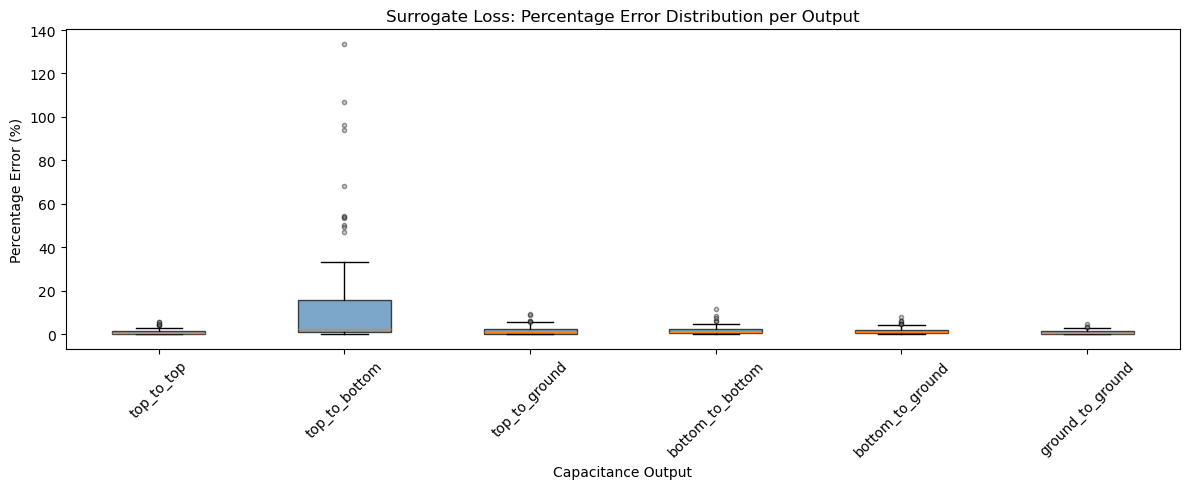

In [11]:
# box plot showing % error distribution per capacitance output 
fig, ax = plt.subplots(figsize=(12, 5))
bp = ax.boxplot(data_per_col, labels=short_names, patch_artist=True, showfliers=True,
                flierprops=dict(marker='o', markersize=3, alpha=0.4, markerfacecolor='grey'))
for patch in bp['boxes']:
    patch.set_facecolor('steelblue')
    patch.set_alpha(0.7)
ax.set_ylabel('Percentage Error (%)')
ax.set_xlabel('Capacitance Output')
ax.set_title('Surrogate Loss: Percentage Error Distribution per Output')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('plots/surrogate_loss_pct_error_boxplot.pdf')
plt.show()

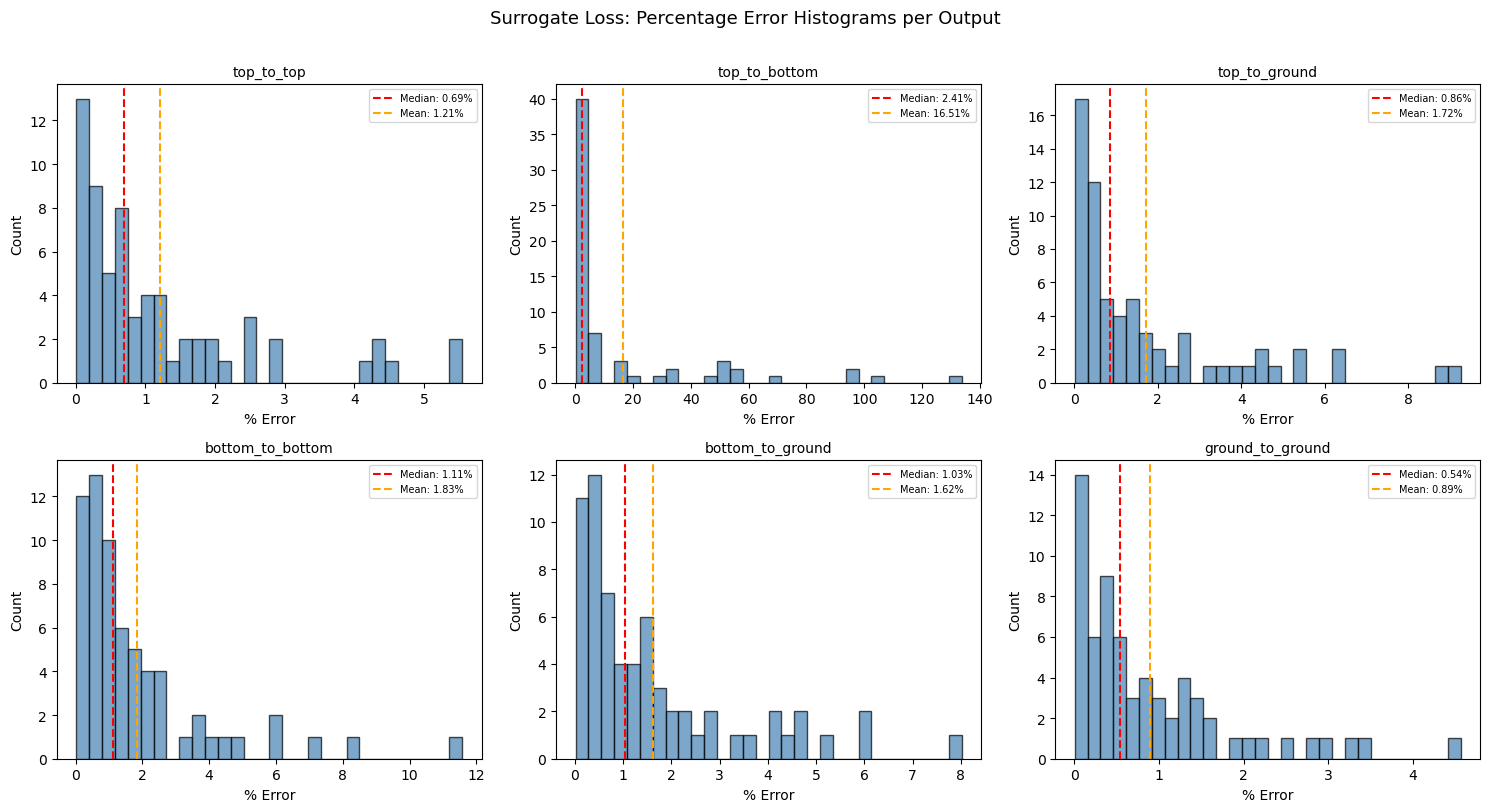

In [12]:
# histogram it too
n_cols_grid = 3
n_rows_grid = math.ceil(n_cap_params / n_cols_grid)

fig, axes = plt.subplots(n_rows_grid, n_cols_grid, figsize=(5 * n_cols_grid, 4 * n_rows_grid))
axes = axes.ravel()

for j in range(n_cap_params):
    col_pct = pct_errors_unscaled[:, j]
    ax = axes[j]
    ax.hist(col_pct, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
    ax.axvline(np.median(col_pct), color='red', linestyle='--',
               label=f'Median: {np.median(col_pct):.2f}%')
    ax.axvline(np.mean(col_pct), color='orange', linestyle='--',
               label=f'Mean: {np.mean(col_pct):.2f}%')
    ax.set_title(short_names[j], fontsize=10)
    ax.set_xlabel('% Error')
    ax.set_ylabel('Count')
    ax.legend(fontsize=7)

for k in range(n_cap_params, len(axes)):
    fig.delaxes(axes[k])

fig.suptitle('Surrogate Loss: Percentage Error Histograms per Output', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('plots/surrogate_loss_pct_error_histograms_per_output.pdf')
plt.show()

In [13]:
#look at the stats nicely
print(f"{'Output':<25s} {'Median %':>10s} {'Mean %':>10s} {'90th %':>10s} {'Max %':>10s}")
print('-' * 70)
for j in range(n_cap_params):
    col_pct = pct_errors_unscaled[:, j]
    name = short_names[j]
    print(f"{name:<25s} {np.median(col_pct):10.2f} {np.mean(col_pct):10.2f} "
          f"{np.percentile(col_pct, 90):10.2f} {np.max(col_pct):10.2f}")
print('-' * 70)
print(f"{'All outputs':<25s} {np.median(all_pct):10.2f} {np.mean(all_pct):10.2f} "
      f"{np.percentile(all_pct, 90):10.2f} {np.max(all_pct):10.2f}")

Output                      Median %     Mean %     90th %      Max %
----------------------------------------------------------------------
top_to_top                      0.69       1.21       2.88       5.55
top_to_bottom                   2.41      16.51      53.67     133.65
top_to_ground                   0.86       1.72       4.61       9.25
bottom_to_bottom                1.11       1.83       4.31      11.58
bottom_to_ground                1.03       1.62       4.35       8.01
ground_to_ground                0.54       0.89       2.15       4.56
----------------------------------------------------------------------
All outputs                     0.95       3.96       5.39     133.65


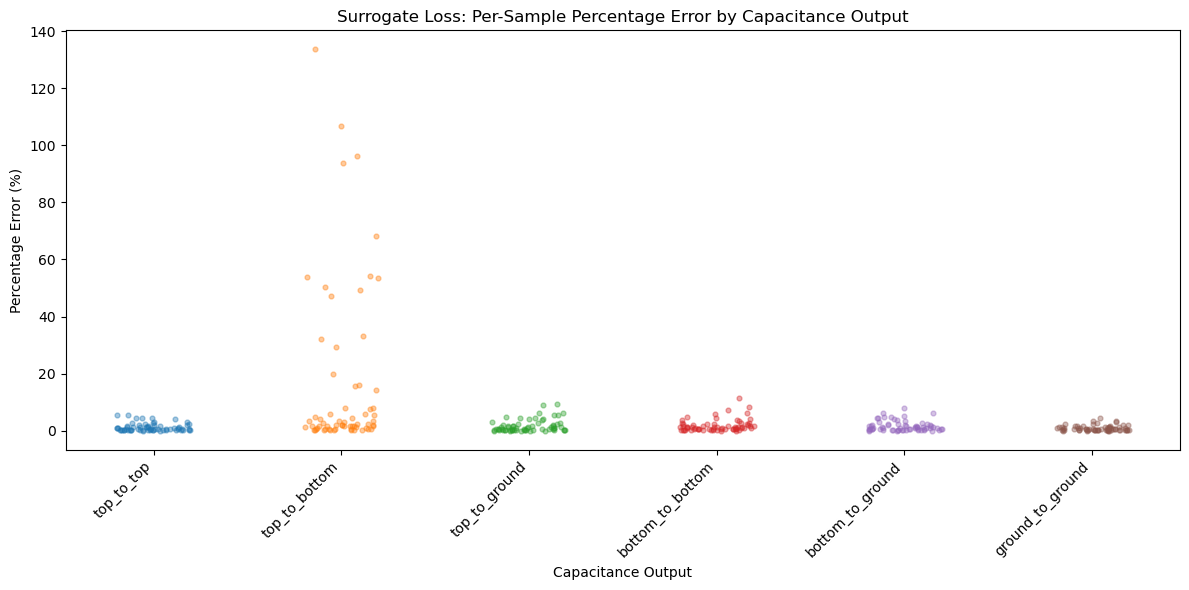

In [14]:
# scatter plot with fancy visulaization of points using this grouping thing

fig, ax = plt.subplots(figsize=(12, 6))
for j in range(n_cap_params):
    col_pct = pct_errors_unscaled[:, j]
    x = np.full_like(col_pct, j) + np.random.uniform(-0.2, 0.2, size=len(col_pct))
    ax.scatter(x, col_pct, alpha=0.4, s=12, label=short_names[j])
ax.set_xticks(range(n_cap_params))
ax.set_xticklabels(short_names, rotation=45, ha='right')
ax.set_ylabel('Percentage Error (%)')
ax.set_xlabel('Capacitance Output')
ax.set_title('Surrogate Loss: Per-Sample Percentage Error by Capacitance Output')
plt.tight_layout()
plt.savefig('plots/surrogate_loss_pct_error_scatter.pdf')
plt.show()

## Finger Count Classification Accuracy 

(no longer matters, but tells us how creative the model is)

In [15]:
# Since finger_count is categorical, lets see how often we get the right class
fc_indices = [qiskit_names.index(c) for c in fc_oh_col_names]

predicted_fcs = np.array([fc_values[np.argmax(qiskit_pred_unscaled[i, fc_indices])] for i in range(n_samples)])
true_fcs      = np.array([fc_values[np.argmax(y_test_unscaled[i, fc_indices])] for i in range(n_samples)])

correct = (predicted_fcs == true_fcs)
accuracy = correct.sum() / len(correct) * 100
print(f'Finger count classification accuracy: {correct.sum()}/{len(correct)} ({accuracy:.1f}%)')

# per-class breakdown
print(f'\n{"True FC":>10s} {"Correct":>10s} {"Total":>10s} {"Accuracy":>10s}')
print('-' * 45)
for fc_val in fc_values:
    mask = (true_fcs == fc_val)
    if mask.sum() > 0:
        n_correct = correct[mask].sum()
        n_total = mask.sum()
        print(f'{fc_val:10d} {n_correct:10d} {n_total:10d} {n_correct/n_total*100:9.1f}%')

# confusion-style: when wrong, what was predicted?
wrong_mask = ~correct
if wrong_mask.sum() > 0:
    print(f'\nMisclassified samples ({wrong_mask.sum()}):')
    print(f'{"True":>10s} {"Predicted":>10s} {"Count":>10s}')
    print('-' * 35)
    wrong_pairs = list(zip(true_fcs[wrong_mask], predicted_fcs[wrong_mask]))
    from collections import Counter
    for (t, p), count in Counter(wrong_pairs).most_common():
        print(f'{t:10d} {p:10d} {count:10d}')

Finger count classification accuracy: 8/65 (12.3%)

   True FC    Correct      Total   Accuracy
---------------------------------------------
         1          4         13      30.8%
         2          0          7       0.0%
         3          0          7       0.0%
         4          0          4       0.0%
         5          0          4       0.0%
         6          0          4       0.0%
         7          0          6       0.0%
         8          0          9       0.0%
         9          0          7       0.0%
        10          4          4     100.0%

Misclassified samples (57):
      True  Predicted      Count
-----------------------------------
         8         10          9
         9         10          7
         3         10          7
         2         10          6
         7         10          6
         1         10          6
         6         10          4
         5         10          4
         1          3          3
         4         10  